In [2]:
import pandas as pd

top_df = pd.read_csv("../results/metal_sensing_app/Metal_sensing_mol.csv")

In [3]:
import os
import subprocess

RESULTS_DIR = os.path.join("..", "results","quantum_screening_data")
INPUT_DIR = os.path.join(RESULTS_DIR, "xtb_inputs")
OUTPUT_DIR = os.path.join(RESULTS_DIR, "xtb_outputs")
SCRATCH_DIR = os.path.join(RESULTS_DIR, "xtb_scratch")

for folder in [INPUT_DIR, OUTPUT_DIR, SCRATCH_DIR]:
    os.makedirs(folder, exist_ok=True)

XTB_PATH = r"D:\xtb-6.6.1\bin\xtb.exe"


In [4]:
'''Generating XYZ coordinates for top molecules using molecular mechanics'''

import shutil
from rdkit import Chem
from rdkit.Chem import AllChem

def generate_3d_xyz(smiles, filename):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
        
    mol = Chem.AddHs(mol)  # Add explicit hydrogens required for 3D coordinates
    
    # Embed using the ETKDGv3 algorithm
    status = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    if status != 0:
        return False
        
    # Quick structural minimization via MMFF94 force field
    AllChem.MMFFOptimizeMolecule(mol)
    
    # Save coordinates as an XYZ file
    Chem.MolToXYZFile(mol, filename)
    return True
    
success_count = 0

for idx, row in top_df.iterrows():
    mol_id = row['Triazine_ID']
    smi = row['SMILES']
    
    filepath = os.path.join(INPUT_DIR, f"{mol_id}.xyz")
    
    if generate_3d_xyz(smi, filepath):
        success_count += 1
    else:
        print(f"Failed to generate 3D structure for {mol_id}")

In [5]:
'''Running Semi-Empirical quantum calculation using xtb to find band gap, HOMO, LUMO and Tot. energy'''

xtb_data = []

# Loop through the generated XYZ inputs
for filename in sorted(os.listdir(INPUT_DIR)):
    if not filename.endswith('.xyz'):
        continue
        
    mol_id = filename.split('.')[0]
    input_path = os.path.abspath(os.path.join(INPUT_DIR, filename))
    log_filepath = os.path.abspath(os.path.join(OUTPUT_DIR, f"{mol_id}.log"))
    
    # Run command: optimize geometry using GFN2 settings
    cmd = f'"{XTB_PATH}" "{input_path}" --opt --gfn 2'
    
    # Execute the command inside SCRATCH_DIR to keep it clean
    with open(log_filepath, "w", encoding="utf-8") as log_file:
        subprocess.run(
            cmd, 
            shell=True, 
            cwd=SCRATCH_DIR, 
            stdout=log_file, 
            stderr=subprocess.PIPE
        )
    
    homo = None
    lumo = None
    total_energy = None
    
    if os.path.exists(log_filepath):
        with open(log_filepath, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                    
                if "(HOMO)" in line:
                    homo = float(parts[-2]) 
                elif "(LUMO)" in line:
                    lumo = float(parts[-2])
                elif "TOTAL ENERGY" in line:
                    try:
                        energy_idx = parts.index("ENERGY") + 1
                        total_energy = float(parts[energy_idx])
                    except (ValueError, IndexError):
                        # Fallback if the table format changes slightly
                        total_energy = float(parts[-3])
        
        if homo is not None and lumo is not None:
            gap = lumo - homo
            xtb_data.append({
                "Triazine_ID": mol_id,
                "HOMO_eV": homo,
                "LUMO_eV": lumo,
                "Gap_eV": gap,
                "E_ligand_au": total_energy
            })

quantum_screening_df = pd.DataFrame(xtb_data)
quantum_df_path = os.path.join(RESULTS_DIR, "xtb_baseline_screening.csv")
quantum_screening_df.to_csv(quantum_df_path, index=False)

print(quantum_screening_df.head())

  Triazine_ID  HOMO_eV  LUMO_eV  Gap_eV  E_ligand_au
0    TRZ00111  -9.3148  -7.6514  1.6634   -65.119353
1    TRZ00112  -9.3357  -7.6995  1.6362   -68.373649
2    TRZ00116  -9.2732  -7.6372  1.6360   -66.005576
3    TRZ00117  -9.5551  -8.6087  0.9464   -69.239724
4    TRZ00127  -9.3024  -7.6669  1.6355   -69.175932


In [6]:
df = pd.merge(
    top_df, 
    quantum_screening_df, 
    on="Triazine_ID"
)
print(df.head())
df.to_csv('../results/metal_sensing_app/top_MS_cand.csv', index=False) 


  Triazine_ID                                             SMILES   MolWt  \
0    TRZ00686  Cc1nnc(-c2ccc3ccc4ccc(-c5nnc(C)c(C)n5)nc4c3n2)...  394.44   
1    TRZ00727              Cc1nnc(-c2ccc(-c3nnc(C)c(C)n3)o2)nc1C  282.31   
2    TRZ01194             Cc1nnc(-c2cccc(-c3nnc(C)c(C)n3)n2)nc1C  293.33   
3    TRZ01492          Cc1nnc(-c2sc(-c3nnc(C)c(C)n3)c(C)c2C)nc1C  326.43   
4    TRZ02619              Cc1nnc(-c2ccc(-c3nnc(C)c(C)n3)s2)nc1C  298.38   

   LogP    TPSA  HBD  HBA  RotatableBonds  AromaticRings  n_triazine_rings  \
0  3.72  103.12    0    8               2              5                 2   
1  2.22   90.48    0    7               2              3                 2   
2  2.02   90.23    0    7               2              3                 2   
3  3.30   77.34    0    7               2              3                 2   
4  2.69   77.34    0    7               2              3                 2   

   ... ring_status total_rings extra_donors  has_plain_phenyl  tridentate 

In [7]:


# Add donor set column manually based on your earlier analysis
donor_sets = {
    'TRZ00686': 'N,N,N,N',  # tetradentate
    'TRZ00727': 'N,O,N',
    'TRZ01194': 'N,N,N',
    'TRZ01492': 'N,S,N',
    'TRZ02619': 'N,S,N',
    'TRZ02802': 'N,N,N',
    'TRZ00111': 'N,O,O',
    'TRZ00112': 'N,O,O',
    'TRZ00116': 'N,O,O,O', # tetradentate
    'TRZ00117': 'N,O,O',
    'TRZ00127': 'N,O,O',
    'TRZ00259': 'N,O,O',
    'TRZ00296': 'N,O,O',
    'TRZ00371': 'N,O,O',
    'TRZ00374': 'N,O,O',
    'TRZ00375': 'N,O,O,O',  # tetradentate
    'TRZ00376': 'N,O,N',
    'TRZ00432': 'N,O,O',
    'TRZ01251': 'N,O,O',
    'TRZ01544': 'N,O,S',
    'TRZ02396': 'N,N,N',
    'TRZ00399': 'N,S,S',
    'TRZ00628': 'N,N,N',
    'TRZ01080': 'N,N,O',
    'TRZ01527': 'N,N,N',
    'TRZ02000': 'N,N,O',
    'TRZ02390': 'N,S,O',
    'TRZ02392': 'N,N,S',
    'TRZ05498': 'N,N,O',
    'TRZ05734': 'N,N,O'
}

df['Donor_Set'] = df['Triazine_ID'].map(donor_sets)
print(df['Donor_Set'].value_counts())

Donor_Set
N,O,O      10
N,N,N       5
N,N,O       4
N,O,N       2
N,S,N       2
N,O,O,O     2
N,N,N,N     1
N,O,S       1
N,S,S       1
N,S,O       1
N,N,S       1
Name: count, dtype: int64


In [8]:
def calculate_cu2_score_v2(row):
    
    # Factor 1 — Donor Set (50 points max)
    donor_scores = {
        'N,N,N,N': 50,
        'N,O,O,O': 42,
        'N,N,N':   45,
        'N,N,O':   40,
        'N,N,S':   35,
        'N,O,N':   40,
        'N,O,O':   35,
        'N,O,S':   30,
        'N,S,O':   30,
        'N,S,N':   35,
        'N,S,S':   25
    }
    donor_score = donor_scores.get(row['Donor_Set'], 0)
    
    # Factor 2 — Band Gap (30 points max)
    gap = row['Gap_eV']
    if 1.0 <= gap <= 1.5:
        gap_score = 30        # ideal range
    elif gap < 1.0:
        gap_score = 15        # too small = unstable
    else:
        gap_score = 9         # too large = weak sensing
    
    # Factor 3 — Bis bonus (10 points max)
    bis_score = 10 if row['n_triazine_rings'] == 2 else 5
    
    total = donor_score + gap_score + bis_score
    
    return round(total, 2)

df['Cu2_Score'] = df.apply(calculate_cu2_score_v2, axis=1)

# Rank
ranked = df[['Triazine_ID','SMILES', 'Donor_Set', 'HOMO_eV','MolWt', 'LogP', 'TPSA', 'HBA',
                        'LUMO_eV', 'Gap_eV', 'n_triazine_rings','Cu2_Score']] \
            .sort_values('Cu2_Score', ascending=False) \
            .reset_index(drop=True)

ranked['Rank'] = ranked.index + 1

print(ranked[['Rank', 'Triazine_ID', 'Donor_Set',
                  'Gap_eV', 'n_triazine_rings',
                  'Cu2_Score']].to_string())

    Rank Triazine_ID Donor_Set  Gap_eV  n_triazine_rings  Cu2_Score
0      1    TRZ00686   N,N,N,N  1.1966                 2         90
1      2    TRZ00727     N,O,N  1.4304                 2         80
2      3    TRZ01527     N,N,N  1.0277                 1         80
3      4    TRZ02396     N,N,N  1.4830                 1         80
4      5    TRZ01492     N,S,N  1.3693                 2         75
5      6    TRZ02619     N,S,N  1.2829                 2         75
6      7    TRZ05498     N,N,O  1.4720                 1         75
7      8    TRZ05734     N,N,O  1.3585                 1         75
8      9    TRZ02392     N,N,S  1.4692                 1         70
9     10    TRZ00628     N,N,N  0.9520                 1         65
10    11    TRZ01194     N,N,N  1.5755                 2         64
11    12    TRZ02802     N,N,N  1.6382                 2         64
12    13    TRZ00375   N,O,O,O  0.8991                 1         62
13    14    TRZ00399     N,S,S  1.3168          

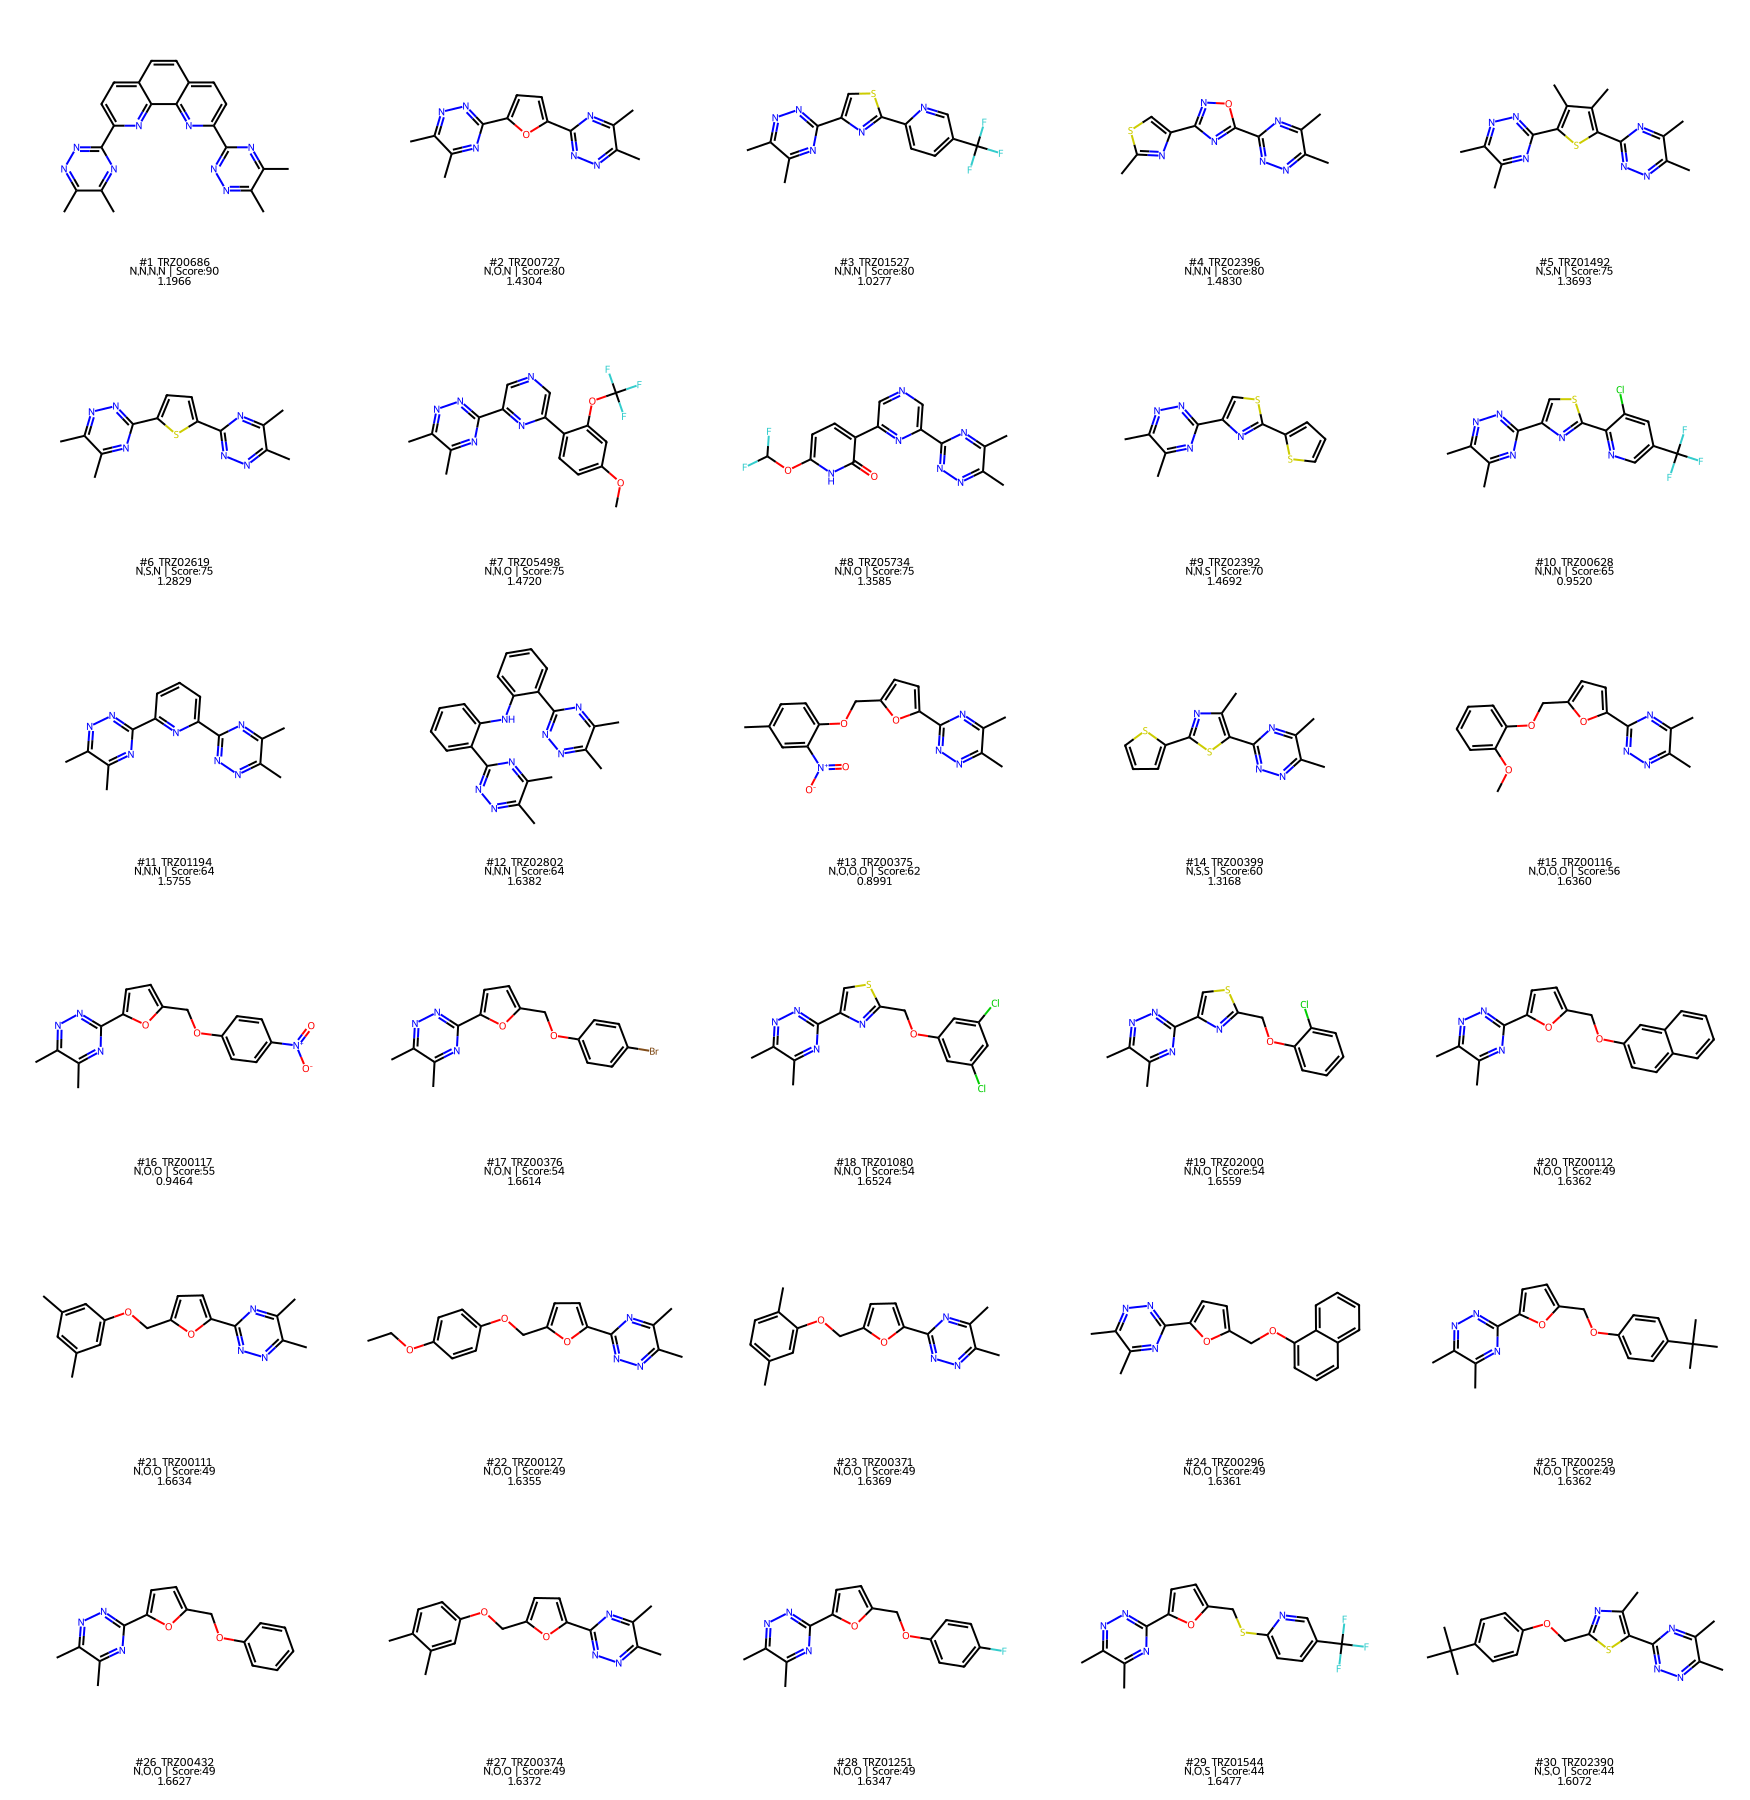

In [9]:
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display

mols = [Chem.MolFromSmiles(s) for s in ranked['SMILES']]

# Legend showing rank, score and donor set
legends = [
    f"#{row['Rank']} {row['Triazine_ID']}\n{row['Donor_Set']} | Score:{row['Cu2_Score']}\n{row['Gap_eV']:.4f}"
    for _, row in ranked.iterrows()
]

img = MolsToGridImage(mols, molsPerRow=5,
                      subImgSize=(350,300),
                      legends=legends)
display(img)

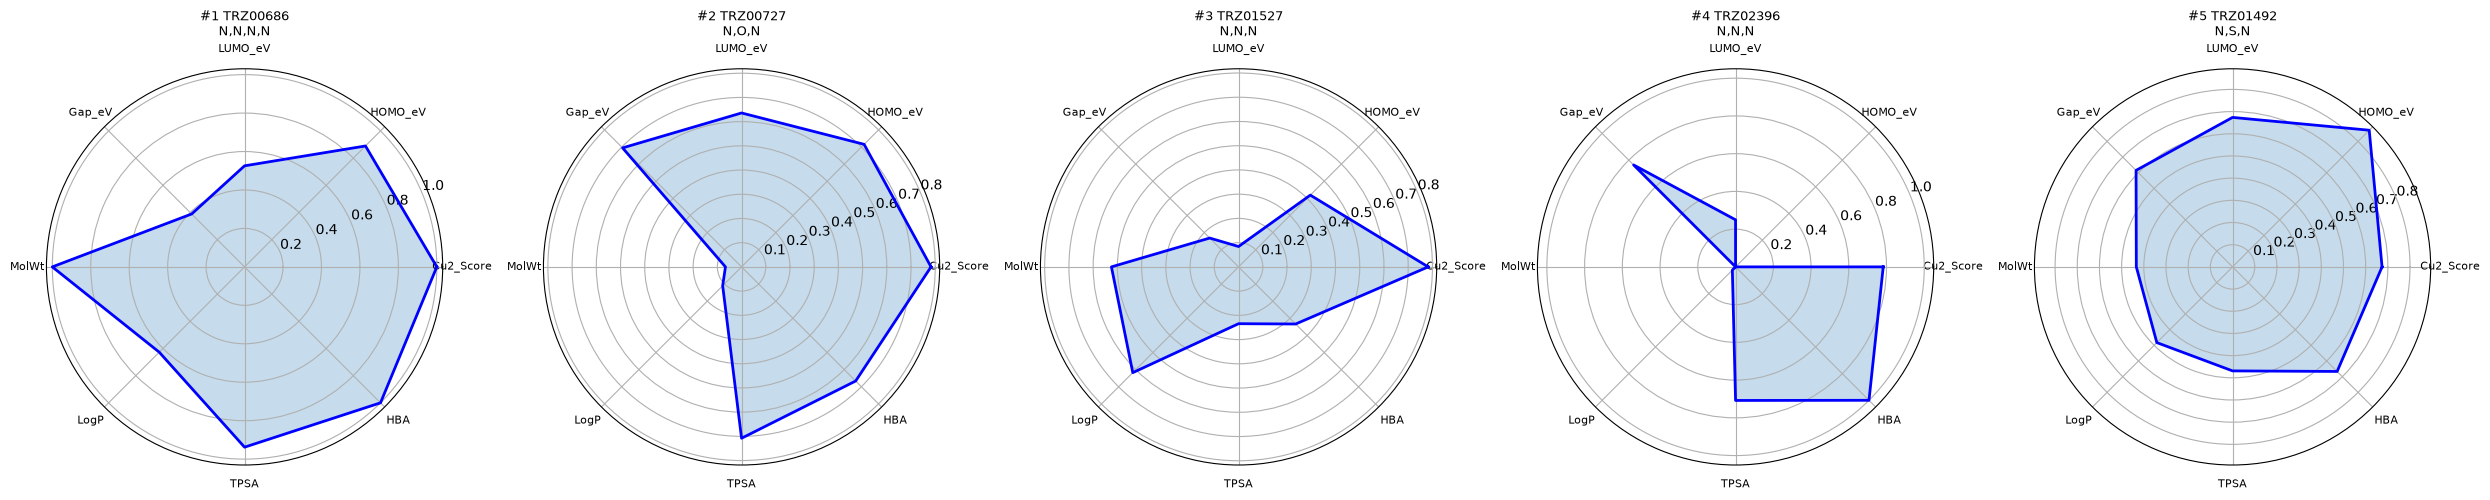

In [10]:
import matplotlib.pyplot as plt
import numpy as np

top5 = ranked.head(5)

categories = ['Cu2_Score', 'HOMO_eV', 'LUMO_eV', 'Gap_eV', 
              'MolWt', 'LogP', 'TPSA', 'HBA']

fig, axes = plt.subplots(1, 5, figsize=(25,5),
                         subplot_kw=dict(polar=True))

for idx, (_, row) in enumerate(top5.iterrows()):
    values = [row[c] for c in categories]
    
    # Normalize each value 0-1
    values_norm = [(v - ranked[c].min()) / 
                   (ranked[c].max() - ranked[c].min() + 1e-9)
                   for v, c in zip(values, categories)]
    
    angles = np.linspace(0, 2*np.pi, len(categories), 
                         endpoint=False).tolist()
    values_norm += values_norm[:1]
    angles += angles[:1]
    
    axes[idx].plot(angles, values_norm, 'b-', linewidth=2)
    axes[idx].fill(angles, values_norm, alpha=0.25)
    axes[idx].set_xticks(angles[:-1])
    axes[idx].set_xticklabels(categories, size=8)
    axes[idx].set_title(f"#{row['Rank']} {row['Triazine_ID']}\n{row['Donor_Set']}", 
                        size=9)

plt.tight_layout()
plt.savefig('../results/figures/top5_radar.png', dpi=150)
plt.show()